## ============================================
## 🌡️ Hopify Segment-Aware Churn Rate Heatmap
## ============================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)


## ================================
## 📥 Load Churn Data from CSV
## ================================

In [9]:
file_path_ret_curve = os.path.join(
    BASE_PATH, "01_project_artifacts", "02_sql_output",
    "01_project_churn_retention_analysis", "07_hopify_retention_curve_signup_cohort.csv"
)

file_path_churn_var = os.path.join(
    BASE_PATH, "01_project_artifacts", "02_sql_output",
    "01_project_churn_retention_analysis", "04_hopify_cohort_churn_var_seg.csv"
)

df_curve = pd.read_csv(file_path_ret_curve)
df_churn = pd.read_csv(file_path_churn_var)

## ================================
## 🧼 Clean Column Names
## ================================

In [10]:
for df in [df_curve, df_churn]:
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("%", "percent")
        .str.replace("-", "_")
        .str.lower()
    )

print("🧪 Retention Curve Columns:", df_curve.columns.tolist())
print("🧪 Churn Var Columns:", df_churn.columns.tolist())

🧪 Retention Curve Columns: ['signup_cohort_month', 'customer_segment', 'months_since_signup', 'remaining_active_customers', 'total_cohort_customers', 'retention_percent']
🧪 Churn Var Columns: ['signup_cohort_month', 'segment', 'churn_month', 'cohort_size', 'churned_customers', 'retention_percent']


## ================================
## 🧮 Compute Churn Rate per Month
## ================================

In [11]:

# Use only df_curve for the heatmap (more granular: cohort × segment × month offset)
df_curve["churn_rate"] = 1 - (df_curve["retention_percent"] / 100)

## ======================================
## 🎯 Segment Loop: Heatmap per Segment
## ======================================

In [12]:
segments = df_curve["customer_segment"].unique()

for segment in segments:
    seg_df = df_curve[df_curve["customer_segment"] == segment].copy()

    # Pivot data to matrix: rows = cohort month, columns = months since signup
    heatmap_data = seg_df.pivot_table(
        index="signup_cohort_month",
        columns="months_since_signup",
        values="churn_rate",
        aggfunc="mean"
    )

## ======================================
## Plot heatmap
## ======================================

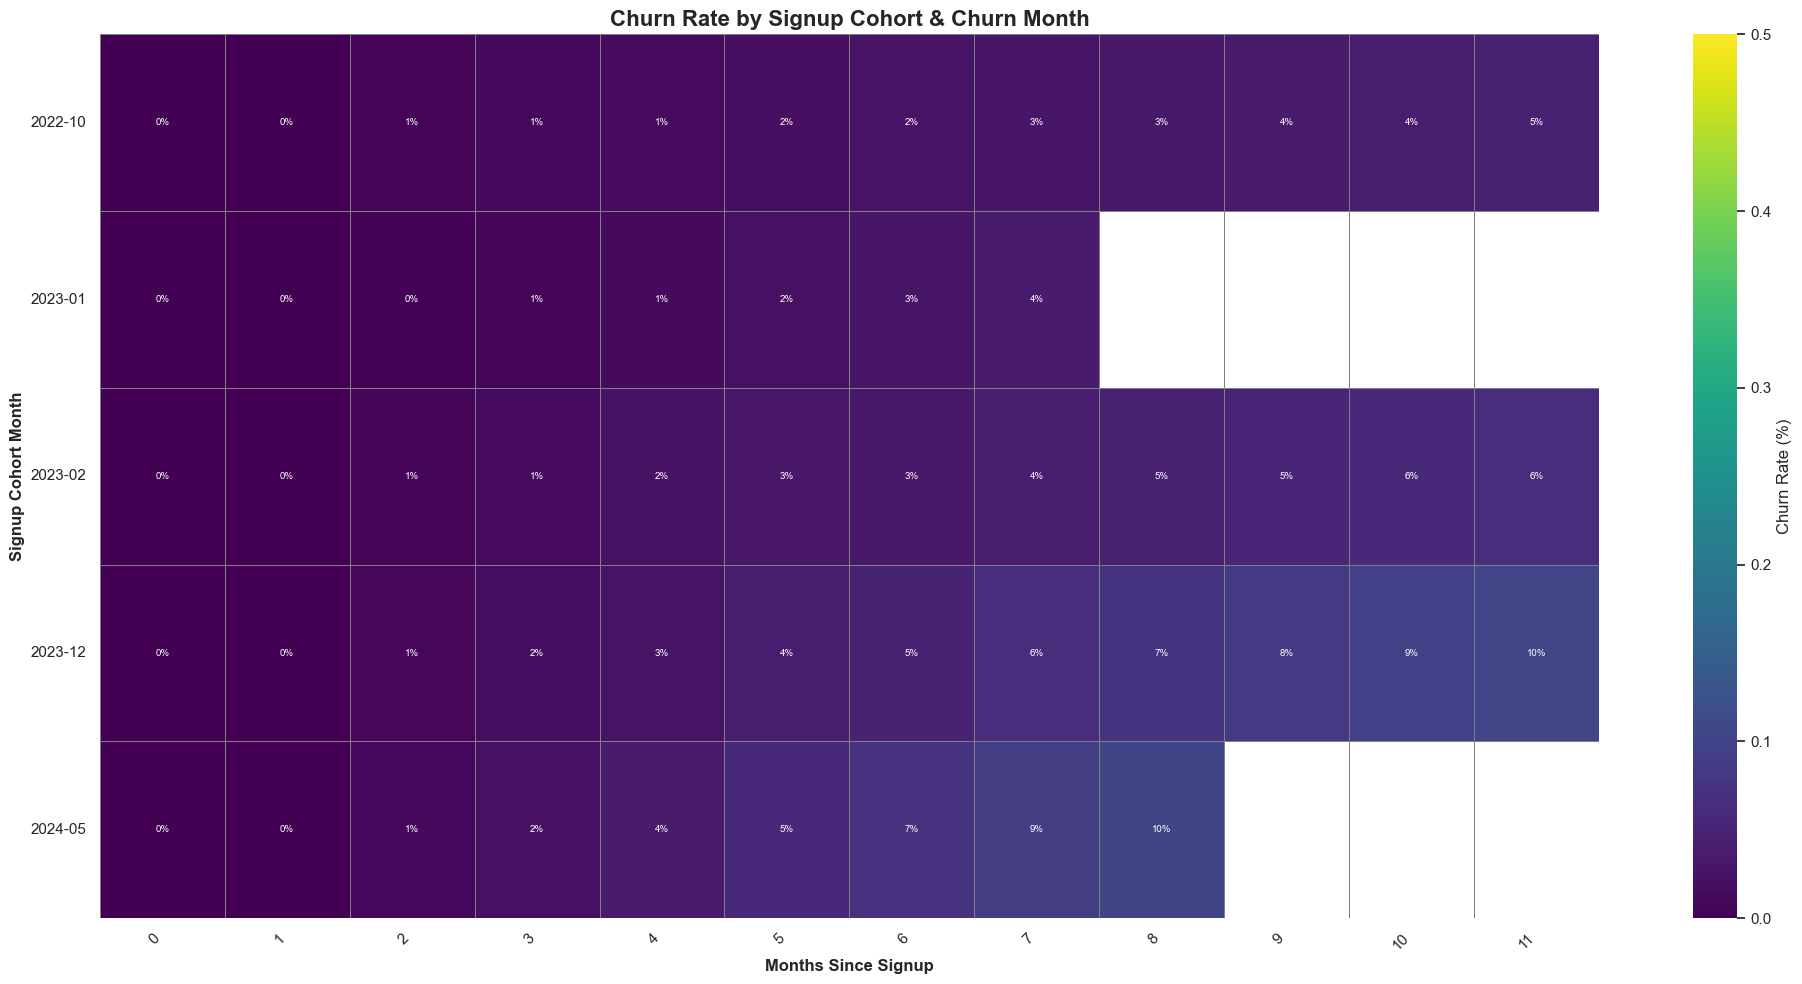

In [13]:
sns.set(style="white")
plt.figure(figsize=(20, 10))

# If max > 1, it's likely percent already, so convert to 0–1 scale
if heatmap_data.max().max() > 1:
    heatmap_data = heatmap_data / 100

ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Churn Rate (%)"},
    annot_kws={"size": 7},
    vmin=0,
    vmax=0.50
)

# Clean tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("Churn Rate by Signup Cohort & Churn Month", fontsize=16, fontweight="bold")
plt.xlabel("Months Since Signup", fontsize=12, fontweight="bold")
plt.ylabel("Signup Cohort Month", fontsize=12, fontweight="bold")
plt.tight_layout()

## ================================
## ✅ Show Plot
## ================================

In [14]:
plt.show()